# Ridge and Lasso Regression From Scratch



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Generate synthetic data

We create informative, correlated, and irrelevant features. The true relationship is approximately:

```text
y = 7*X1 - 5*X2 + 3*X3 + noise
```

The remaining features should ideally have very small or zero coefficients.

In [3]:
n_samples = 350

X1 = np.random.normal(0, 1, n_samples)
X2 = np.random.normal(0, 1, n_samples)
X3 = np.random.normal(0, 1, n_samples)

# Correlated copies
X4 = X1 + np.random.normal(0, 0.15, n_samples)
X5 = X2 + np.random.normal(0, 0.15, n_samples)

# Irrelevant features
X6 = np.random.normal(0, 1, n_samples)
X7 = np.random.normal(0, 1, n_samples)
X8 = np.random.normal(0, 1, n_samples)
X9 = np.random.normal(0, 1, n_samples)
X10 = np.random.normal(0, 1, n_samples)

X = np.column_stack([X1,X2,X3,X4,X5,X6,X7,X8,X9,X10])
feature_names = [f"X{i}" for i in range(1, 11)]
true_coefficients = np.array([7,-5,3,0,0,0,0,0,0,0])
noise = np.random.normal(0, 3, n_samples)
y = X @ true_coefficients + noise

df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y
display(df.head())
print("Shape:", df.shape)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Target
0,-0.524662,0.243657,1.393181,-0.583444,0.098790,-0.188202,0.136597,-0.221600,0.257253,0.785185,-3.457810
1,0.493655,-1.090208,0.839349,0.340990,-1.170994,-0.103587,0.025385,-1.440982,-0.344477,-1.777681,11.804051
2,1.296063,-0.985540,0.872824,1.141953,-1.055553,-0.213875,-0.716573,0.958816,-0.749416,0.714746,15.110006
3,-1.107157,-0.969744,-0.966157,-1.163147,-1.192191,0.970316,0.809594,1.127686,0.337766,-0.233724,-2.263251
4,-0.365506,0.110535,-0.079388,-0.268828,-0.012117,0.418760,0.530894,-1.947342,-0.545087,0.707458,0.584103


Shape: (350, 11)


In [4]:
display(pd.DataFrame({"Feature": feature_names, "True coefficient": true_coefficients}))

,Feature,True coefficient
0,X1,7
1,X2,-5
2,X3,3
3,X4,0
4,X5,0
5,X6,0
6,X7,0
7,X8,0
8,X9,0
9,X10,0


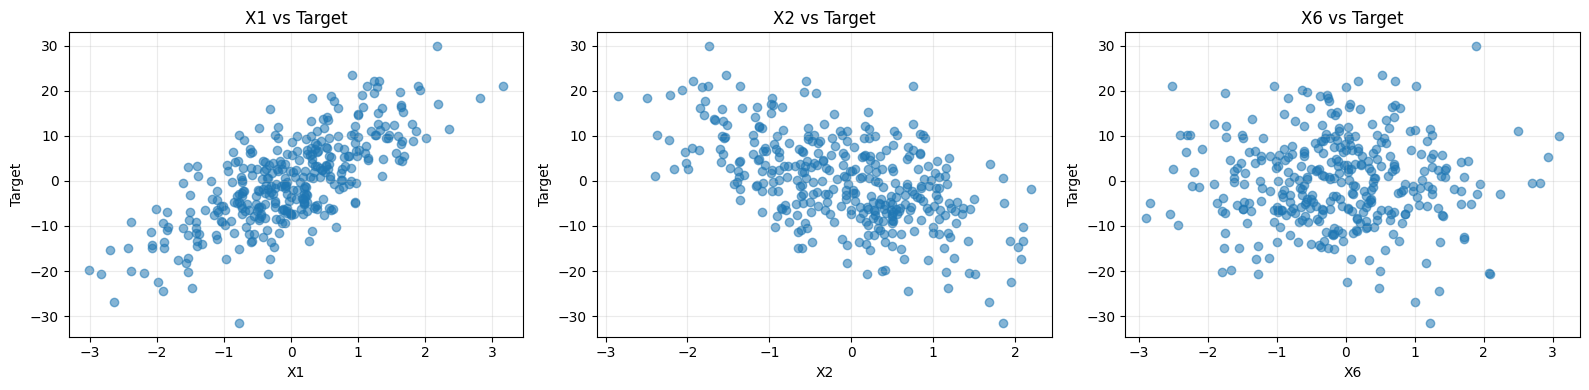

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feature, values in zip(axes, ["X1","X2","X6"], [X1,X2,X6]):
    ax.scatter(values, y, alpha=0.55)
    ax.set_title(f"{feature} vs Target")
    ax.set_xlabel(feature)
    ax.set_ylabel("Target")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Train/test split and standardization

Scaling is important because Ridge and Lasso penalize coefficient magnitude. We standardize the features before training.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)

Train: (262, 10)
Test : (88, 10)


## 6. Baseline Linear Regression

In [7]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_predictions = linear_model.predict(X_test_scaled)

linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MSE : 11.941532357120577
RMSE: 3.455652233243469
R²  : 0.8167971899072703


# PART A — RIDGE REGRESSION FROM SCRATCH

In [8]:
class RidgeRegressionScratch:
    def __init__(self, learning_rate=0.01, alpha=0.1, epochs=3000):
        self.learning_rate = learning_rate
        self.alpha = alpha
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.mse_history = []
        self.penalty_history = []
        self.weight_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y

            mse = np.mean(error ** 2)
            l2_penalty = self.alpha * np.sum(self.weights ** 2)
            total_loss = mse + l2_penalty

            dw = (2 / n_samples) * (X.T @ error) + 2 * self.alpha * self.weights
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            self.loss_history.append(total_loss)
            self.mse_history.append(mse)
            self.penalty_history.append(l2_penalty)
            self.weight_history.append(self.weights.copy())

        self.weight_history = np.array(self.weight_history)
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

In [9]:
ridge_scratch = RidgeRegressionScratch(learning_rate=0.01, alpha=0.10, epochs=3000)
ridge_scratch.fit(X_train_scaled, y_train)
ridge_scratch_predictions = ridge_scratch.predict(X_test_scaled)

ridge_scratch_mse = mean_squared_error(y_test, ridge_scratch_predictions)
ridge_scratch_rmse = np.sqrt(ridge_scratch_mse)
ridge_scratch_r2 = r2_score(y_test, ridge_scratch_predictions)

print("Ridge From Scratch")
print("MSE :", ridge_scratch_mse)
print("RMSE:", ridge_scratch_rmse)
print("R²  :", ridge_scratch_r2)

Ridge From Scratch
MSE : 12.110189634371626
RMSE: 3.4799697749221363
R²  : 0.8142097089868209


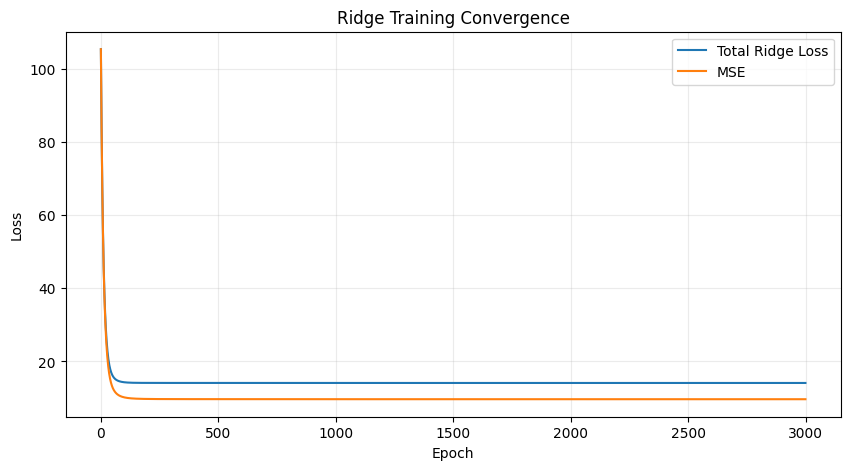

In [10]:
plt.figure(figsize=(10,5))
plt.plot(ridge_scratch.loss_history, label="Total Ridge Loss")
plt.plot(ridge_scratch.mse_history, label="MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ridge Training Convergence")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

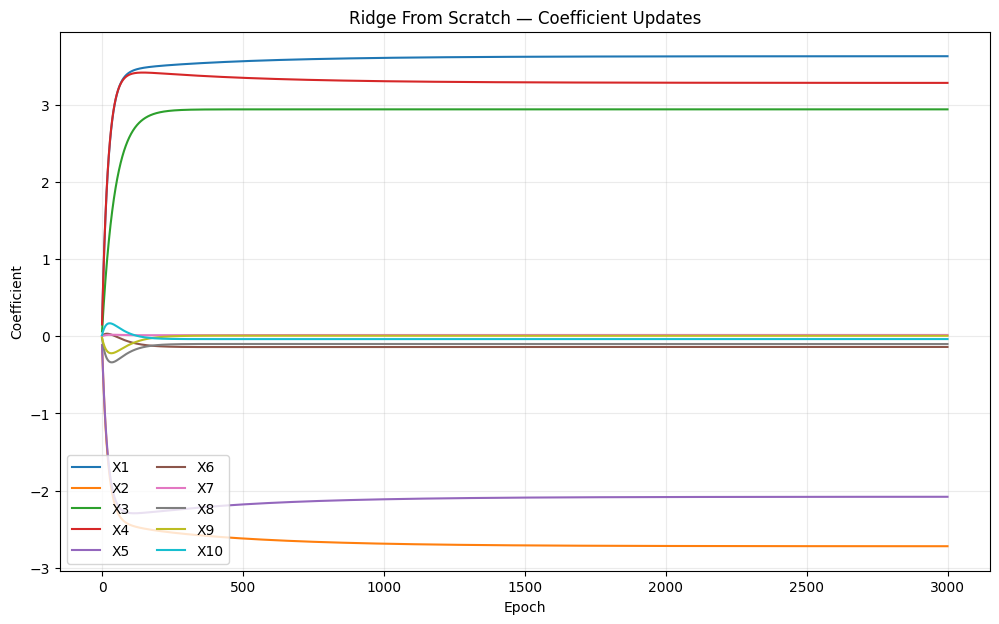

In [11]:
plt.figure(figsize=(12,7))
for i, feature in enumerate(feature_names):
    plt.plot(ridge_scratch.weight_history[:, i], label=feature)
plt.xlabel("Epoch")
plt.ylabel("Coefficient")
plt.title("Ridge From Scratch — Coefficient Updates")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.show()

# PART B — LASSO REGRESSION FROM SCRATCH

In [12]:
def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0)

class LassoRegressionScratch:
    def __init__(self, learning_rate=0.01, alpha=0.25, epochs=5000):
        self.learning_rate = learning_rate
        self.alpha = alpha
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.mse_history = []
        self.penalty_history = []
        self.weight_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y

            grad_w = (2 / n_samples) * (X.T @ error)
            grad_b = (2 / n_samples) * np.sum(error)

            temp_weights = self.weights - self.learning_rate * grad_w
            self.weights = soft_threshold(
                temp_weights, self.learning_rate * self.alpha
            )
            self.bias -= self.learning_rate * grad_b

            new_pred = X @ self.weights + self.bias
            mse = np.mean((new_pred - y) ** 2)
            l1_penalty = self.alpha * np.sum(np.abs(self.weights))
            total_loss = mse + l1_penalty

            self.loss_history.append(total_loss)
            self.mse_history.append(mse)
            self.penalty_history.append(l1_penalty)
            self.weight_history.append(self.weights.copy())

        self.weight_history = np.array(self.weight_history)
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

In [13]:
example_values = np.array([-2.0,-0.7,-0.2,0.0,0.2,0.7,2.0])
threshold = 0.5
display(pd.DataFrame({
    "Original value": example_values,
    "After soft threshold": soft_threshold(example_values, threshold)
}))

,Original value,After soft threshold
0,-2.0,-1.5
1,-0.7,-0.2
2,-0.2,-0.0
3,0.0,0.0
4,0.2,0.0
5,0.7,0.2
6,2.0,1.5


In [14]:
lasso_scratch = LassoRegressionScratch(learning_rate=0.01, alpha=0.25, epochs=5000)
lasso_scratch.fit(X_train_scaled, y_train)
lasso_scratch_predictions = lasso_scratch.predict(X_test_scaled)

lasso_scratch_mse = mean_squared_error(y_test, lasso_scratch_predictions)
lasso_scratch_rmse = np.sqrt(lasso_scratch_mse)
lasso_scratch_r2 = r2_score(y_test, lasso_scratch_predictions)

print("Lasso From Scratch")
print("MSE :", lasso_scratch_mse)
print("RMSE:", lasso_scratch_rmse)
print("R²  :", lasso_scratch_r2)

Lasso From Scratch
MSE : 11.833480273775264
RMSE: 3.4399825978884344
R²  : 0.81845488715359


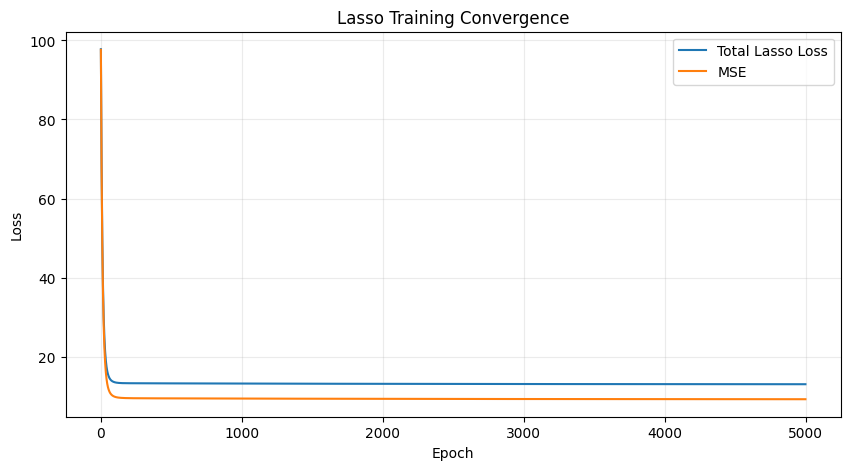

In [15]:
plt.figure(figsize=(10,5))
plt.plot(lasso_scratch.loss_history, label="Total Lasso Loss")
plt.plot(lasso_scratch.mse_history, label="MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Lasso Training Convergence")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

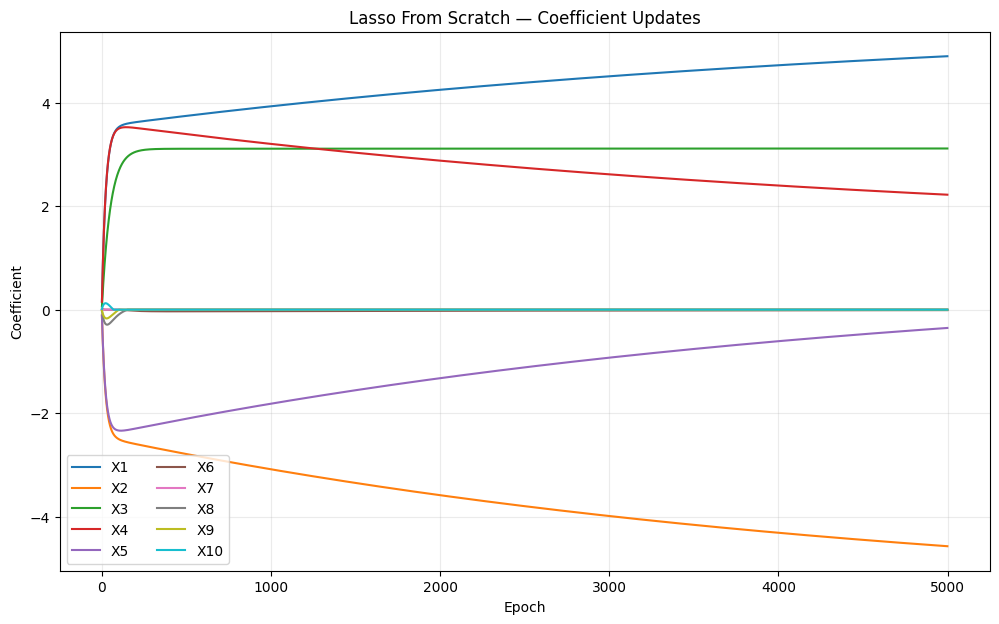

In [16]:
plt.figure(figsize=(12,7))
for i, feature in enumerate(feature_names):
    plt.plot(lasso_scratch.weight_history[:, i], label=feature)
plt.xlabel("Epoch")
plt.ylabel("Coefficient")
plt.title("Lasso From Scratch — Coefficient Updates")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.show()

## 7. Compare coefficients

In [17]:
coefficient_comparison = pd.DataFrame({
    "Feature": feature_names,
    "True": true_coefficients,
    "Linear": linear_model.coef_,
    "Ridge Scratch": ridge_scratch.weights,
    "Lasso Scratch": lasso_scratch.weights
})
display(coefficient_comparison)

,Feature,True,Linear,Ridge Scratch,Lasso Scratch
0,X1,7,5.795028,3.632599,4.898819
1,X2,-5,-5.667146,-2.722135,-4.573167
2,X3,3,3.252606,2.943495,3.115279
3,X4,0,1.430462,3.286836,2.221940
4,X5,0,0.606274,-2.081011,-0.354001
5,X6,0,-0.138057,-0.138103,-0.009205
6,X7,0,0.055721,0.017749,0.000000
7,X8,0,-0.064785,-0.099883,-0.000000
8,X9,0,0.017504,0.006891,-0.000000
9,X10,0,-0.066069,-0.035937,-0.000000


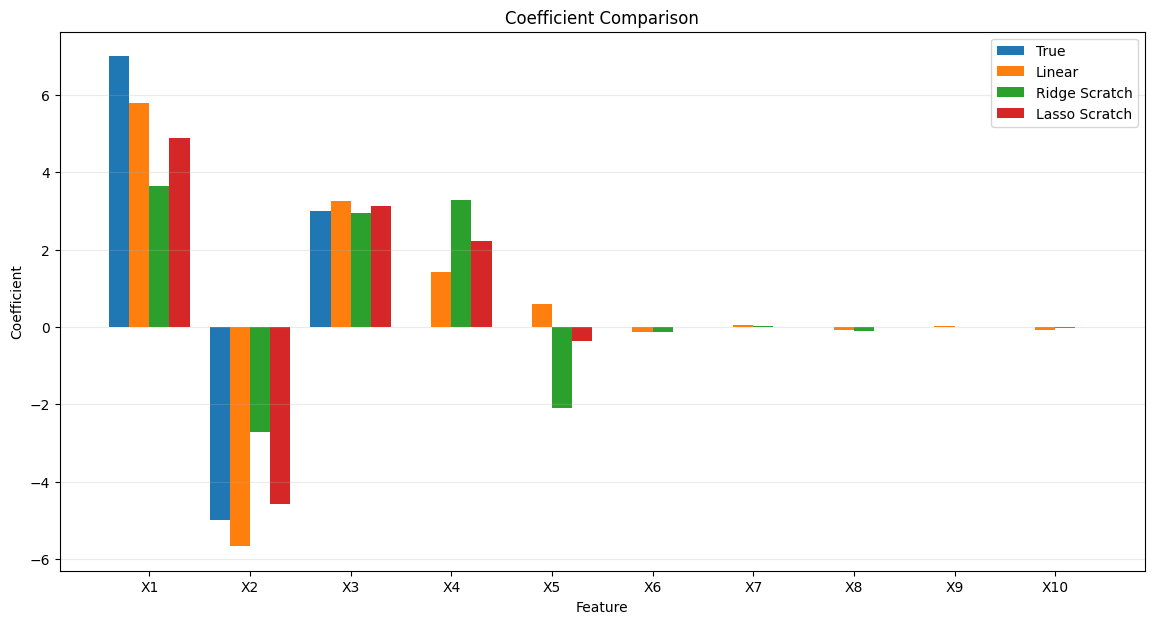

In [18]:
x = np.arange(len(feature_names))
width = 0.20
plt.figure(figsize=(14,7))
plt.bar(x - 1.5*width, true_coefficients, width, label="True")
plt.bar(x - 0.5*width, linear_model.coef_, width, label="Linear")
plt.bar(x + 0.5*width, ridge_scratch.weights, width, label="Ridge Scratch")
plt.bar(x + 1.5*width, lasso_scratch.weights, width, label="Lasso Scratch")
plt.xticks(x, feature_names)
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.title("Coefficient Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

## 8. Compare predictive performance

In [19]:
scratch_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge From Scratch", "Lasso From Scratch"],
    "MSE": [linear_mse, ridge_scratch_mse, lasso_scratch_mse],
    "RMSE": [linear_rmse, ridge_scratch_rmse, lasso_scratch_rmse],
    "R²": [linear_r2, ridge_scratch_r2, lasso_scratch_r2]
})
display(scratch_results)

,Model,MSE,RMSE,R²
0,Linear Regression,11.941532,3.455652,0.816797
1,Ridge From Scratch,12.110190,3.479970,0.814210
2,Lasso From Scratch,11.833480,3.439983,0.818455


# PART C — EFFECT OF ALPHA

In [20]:
ridge_alphas = [0.0,0.001,0.01,0.05,0.1,0.25,0.5,1.0]
ridge_alpha_coefficients = []

for alpha in ridge_alphas:
    model = RidgeRegressionScratch(learning_rate=0.01, alpha=alpha, epochs=2500)
    model.fit(X_train_scaled, y_train)
    ridge_alpha_coefficients.append(model.weights)

ridge_alpha_coefficients = np.array(ridge_alpha_coefficients)
display(pd.DataFrame(ridge_alpha_coefficients, index=ridge_alphas, columns=feature_names))

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0.000,4.451448,-3.836959,3.250483,2.792667,-1.197697,-0.164840,0.030374,-0.054483,0.049007,-0.073867
0.001,4.430553,-3.806460,3.247075,2.810338,-1.225521,-0.164772,0.029997,-0.054907,0.048799,-0.073496
0.010,4.267108,-3.569457,3.216759,2.944552,-1.439041,-0.163712,0.027094,-0.058859,0.046414,-0.070079
0.050,3.859289,-3.001424,3.089052,3.221074,-1.911167,-0.153737,0.020472,-0.077536,0.030033,-0.054455
0.100,3.632065,-2.721335,2.943494,3.287378,-2.081801,-0.138114,0.017738,-0.099878,0.006904,-0.035939
0.250,3.298420,-2.399496,2.580055,3.177160,-2.110605,-0.097636,0.016037,-0.151900,-0.049230,0.008485
0.500,2.947552,-2.129528,2.141242,2.904572,-1.971253,-0.054402,0.015880,-0.201663,-0.103110,0.055026
1.000,2.459370,-1.782621,1.599551,2.452802,-1.695062,-0.012954,0.015747,-0.235892,-0.142817,0.096560


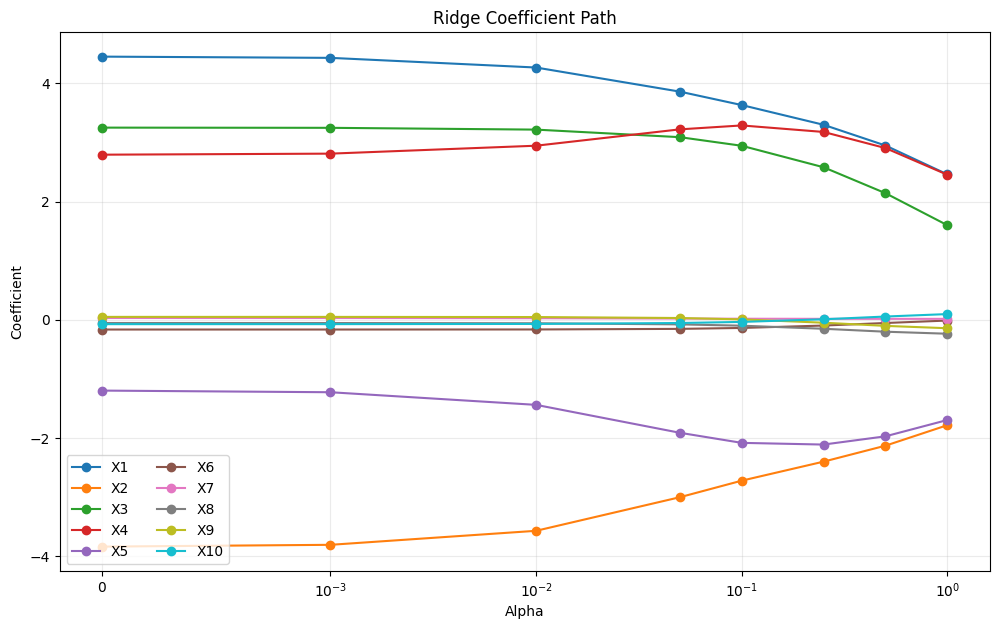

In [21]:
plt.figure(figsize=(12,7))
for i, feature in enumerate(feature_names):
    plt.plot(ridge_alphas, ridge_alpha_coefficients[:,i], marker="o", label=feature)
plt.xscale("symlog", linthresh=0.001)
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Ridge Coefficient Path")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.show()

In [22]:
lasso_alphas = [0.0,0.01,0.05,0.1,0.25,0.5,1.0]
lasso_alpha_coefficients = []

for alpha in lasso_alphas:
    model = LassoRegressionScratch(learning_rate=0.01, alpha=alpha, epochs=3500)
    model.fit(X_train_scaled, y_train)
    lasso_alpha_coefficients.append(model.weights)

lasso_alpha_coefficients = np.array(lasso_alpha_coefficients)
display(pd.DataFrame(lasso_alpha_coefficients, index=lasso_alphas, columns=feature_names))

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0.00,4.689992,-4.192350,3.250820,2.550580,-0.846918,-0.159935,0.035041,-0.056540,0.043115,-0.072610
0.01,4.688058,-4.190600,3.244986,2.547953,-0.843356,-0.153598,0.029623,-0.051858,0.036159,-0.067045
0.05,4.681097,-4.183943,3.221653,2.536667,-0.828785,-0.128238,0.007965,-0.033129,0.008322,-0.044779
0.10,4.674264,-4.176780,3.194981,2.519799,-0.813330,-0.098341,0.000000,-0.010704,0.000000,-0.017676
0.25,4.622881,-4.159957,3.114131,2.501809,-0.760565,-0.014734,0.000000,-0.000000,0.000000,-0.000000
0.50,4.492147,-4.125177,2.987137,2.518609,-0.680562,-0.000000,0.000000,-0.000000,-0.000000,-0.000000
1.00,4.217313,-4.051355,2.735302,2.565544,-0.525405,-0.000000,0.000000,-0.000000,-0.000000,-0.000000


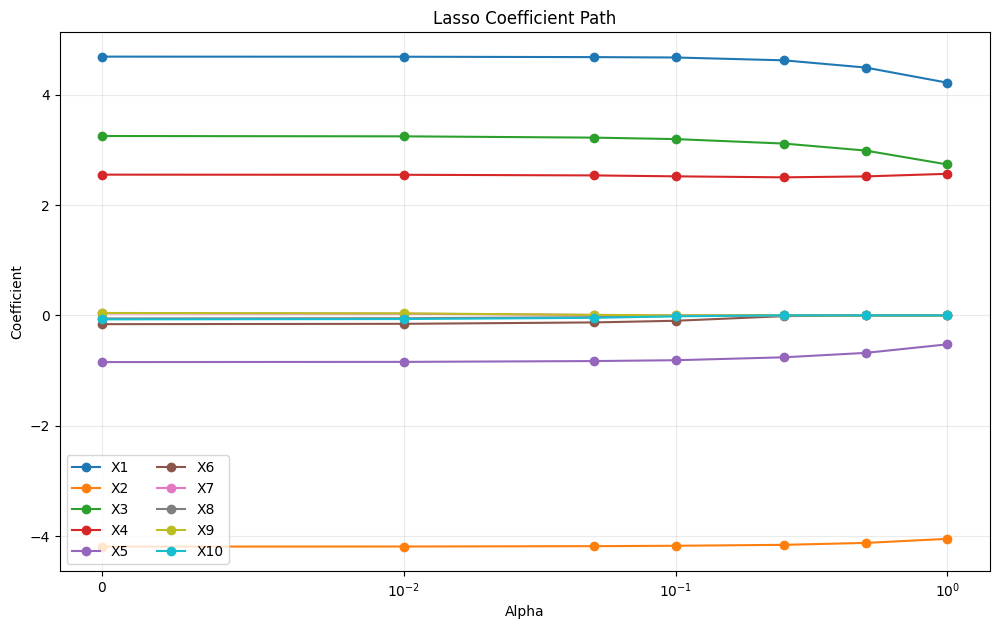

In [23]:
plt.figure(figsize=(12,7))
for i, feature in enumerate(feature_names):
    plt.plot(lasso_alphas, lasso_alpha_coefficients[:,i], marker="o", label=feature)
plt.xscale("symlog", linthresh=0.01)
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Lasso Coefficient Path")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.show()

## Alpha intuition

### Ridge

```text
larger alpha
   ↓
stronger L2 penalty
   ↓
smaller coefficient magnitudes
```

### Lasso

```text
larger alpha
   ↓
stronger L1 penalty
   ↓
coefficients shrink
   ↓
some become exactly zero
```


# PART D — SCIKIT-LEARN COMPARISON

In [24]:
sklearn_ridge = Ridge(alpha=0.10)
sklearn_ridge.fit(X_train_scaled, y_train)
ridge_sk_predictions = sklearn_ridge.predict(X_test_scaled)

sklearn_lasso = Lasso(alpha=0.25, max_iter=10000, random_state=42)
sklearn_lasso.fit(X_train_scaled, y_train)
lasso_sk_predictions = sklearn_lasso.predict(X_test_scaled)

In [25]:
models = {
    "Linear Regression": linear_predictions,
    "Ridge Scratch": ridge_scratch_predictions,
    "Ridge sklearn": ridge_sk_predictions,
    "Lasso Scratch": lasso_scratch_predictions,
    "Lasso sklearn": lasso_sk_predictions
}

rows = []
for name, pred in models.items():
    mse = mean_squared_error(y_test, pred)
    rows.append({
        "Model": name,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_test, pred)
    })

display(pd.DataFrame(rows))

,Model,MSE,RMSE,R²
0,Linear Regression,11.941532,3.455652,0.816797
1,Ridge Scratch,12.110190,3.479970,0.814210
2,Ridge sklearn,11.949625,3.456823,0.816673
3,Lasso Scratch,11.833480,3.439983,0.818455
4,Lasso sklearn,11.659178,3.414554,0.821129


In [26]:
display(pd.DataFrame({
    "Feature": feature_names,
    "True": true_coefficients,
    "Linear": linear_model.coef_,
    "Ridge Scratch": ridge_scratch.weights,
    "Ridge sklearn": sklearn_ridge.coef_,
    "Lasso Scratch": lasso_scratch.weights,
    "Lasso sklearn": sklearn_lasso.coef_
}))

,Feature,True,Linear,Ridge Scratch,Ridge sklearn,Lasso Scratch,Lasso sklearn
0,X1,7,5.795028,3.632599,5.711981,4.898819,5.515310
1,X2,-5,-5.667146,-2.722135,-5.559495,-4.573167,-4.838922
2,X3,3,3.252606,2.943495,3.251178,3.115279,2.992580
3,X4,0,1.430462,3.286836,1.513270,2.221940,1.486572
4,X5,0,0.606274,-2.081011,0.501117,-0.354001,-0.000000
5,X6,0,-0.138057,-0.138103,-0.139497,-0.009205,-0.000000
6,X7,0,0.055721,0.017749,0.054195,0.000000,0.000000
7,X8,0,-0.064785,-0.099883,-0.064418,-0.000000,-0.000000
8,X9,0,0.017504,0.006891,0.019123,-0.000000,-0.000000
9,X10,0,-0.066069,-0.035937,-0.066389,-0.000000,-0.000000


## 9. Which features did Lasso remove?

In [27]:
zero_features = [
    feature_names[i]
    for i, coef in enumerate(lasso_scratch.weights)
    if np.isclose(coef, 0.0, atol=1e-8)
]

print("Features set to zero by scratch Lasso:", zero_features)
print("Non-zero coefficients:", np.count_nonzero(~np.isclose(lasso_scratch.weights, 0.0, atol=1e-8)))

Features set to zero by scratch Lasso: ['X7', 'X8', 'X9', 'X10']
Non-zero coefficients: 6


## 10. Actual vs predicted

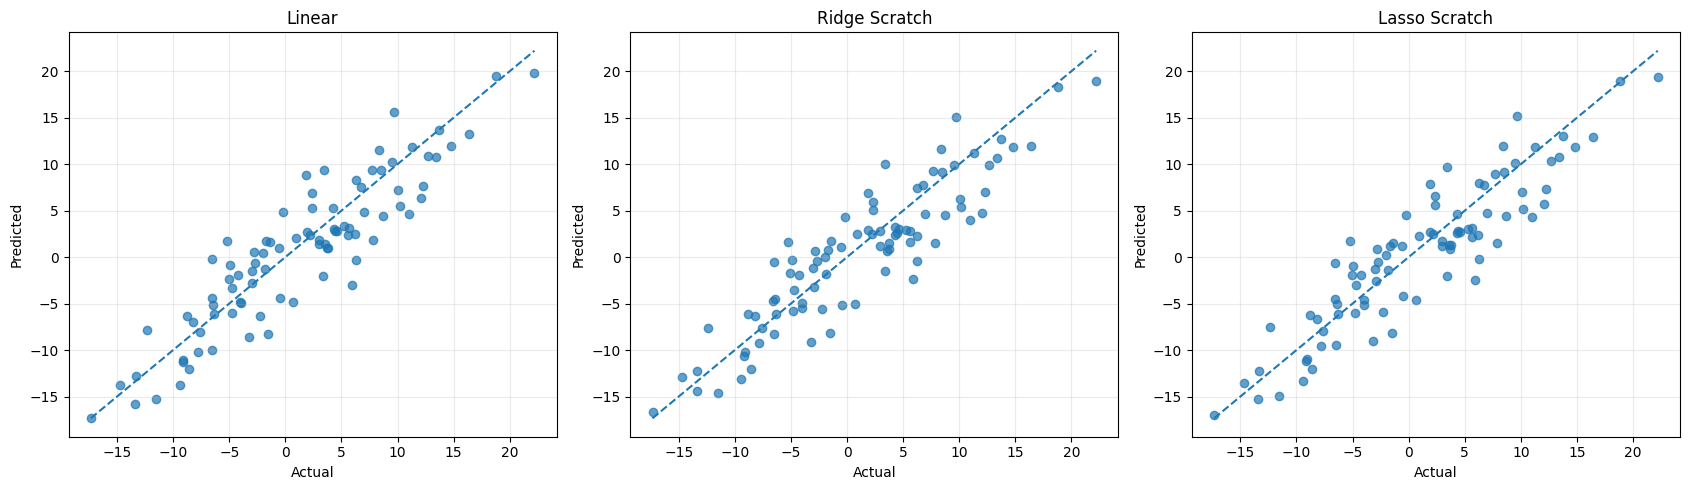

In [28]:
models_to_plot = {
    "Linear": linear_predictions,
    "Ridge Scratch": ridge_scratch_predictions,
    "Lasso Scratch": lasso_scratch_predictions
}

fig, axes = plt.subplots(1,3,figsize=(17,5))
minimum = min(y_test.min(), *(p.min() for p in models_to_plot.values()))
maximum = max(y_test.max(), *(p.max() for p in models_to_plot.values()))

for ax, (name, pred) in zip(axes, models_to_plot.items()):
    ax.scatter(y_test, pred, alpha=0.7)
    ax.plot([minimum,maximum], [minimum,maximum], linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# 11. Final mathematical comparison

### Linear Regression

\[
J=MSE
\]

### Ridge Regression

\[
J_{ridge}=MSE+\alpha\sum_jw_j^2
\]

- L2 regularization
- smooth and differentiable
- shrinks coefficients
- useful with correlated predictors

### Lasso Regression

\[
J_{lasso}=MSE+\alpha\sum_j|w_j|
\]

- L1 regularization
- non-differentiable at zero
- can create sparse models
- can perform feature selection


# 12. Ridge vs Lasso at a glance

| Property | Linear | Ridge (L2) | Lasso (L1) |
|---|---|---|---|
| Regularization | No | Yes | Yes |
| Penalty | None | Squared coefficients | Absolute coefficients |
| Shrinks coefficients | No | Yes | Yes |
| Exact zeros | Usually no | Usually no | Yes |
| Feature selection | No | No | Yes |
| Helpful with correlated features | Limited | Often very useful | Can choose among them |
| Main optimization issue | None special | Smooth | Non-smooth at zero |


# Complete workflow

```text
Regression Data
     ↓
Train/Test Split
     ↓
Standardization
     ↓
Linear Baseline
     ↓
Ridge: MSE + alpha * Σw²
     ↓
Gradient Descent
     ↓
Coefficient Shrinkage
     ↓
Lasso: MSE + alpha * Σ|w|
     ↓
Gradient Step + Soft Thresholding
     ↓
Sparse Coefficients
     ↓
Compare MSE / RMSE / R²
     ↓
Study coefficient paths vs alpha
```
